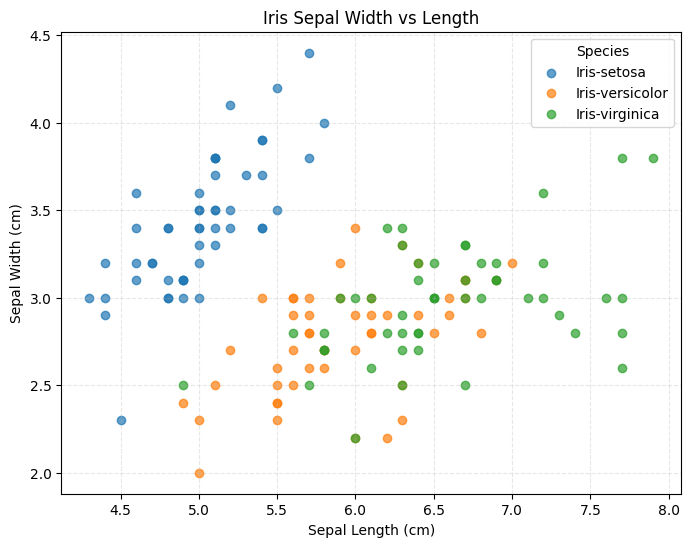

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/irisdata/IRIS.csv")

plt.figure(figsize=(8, 6))
for species, group in df.groupby("species"):
    plt.scatter(group["sepal_length"], group["sepal_width"], label=species, alpha=0.7)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Iris Sepal Width vs Length")
plt.legend(title="Species")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

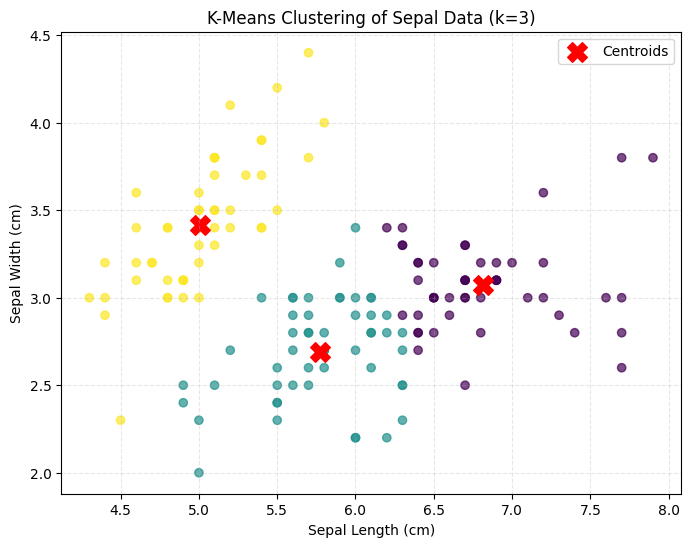

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv("data/irisdata/IRIS.csv")

# Pretend we only have the sepal measurements (no species labels)
X = df[["sepal_length", "sepal_width"]]

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X["sepal_length"], X["sepal_width"], c=labels, cmap="viridis", alpha=0.7)
plt.scatter(centers[:, 0], centers[:, 1], c="red", marker="X", s=200, label="Centroids")

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title(f"K-Means Clustering of Sepal Data (k={k})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

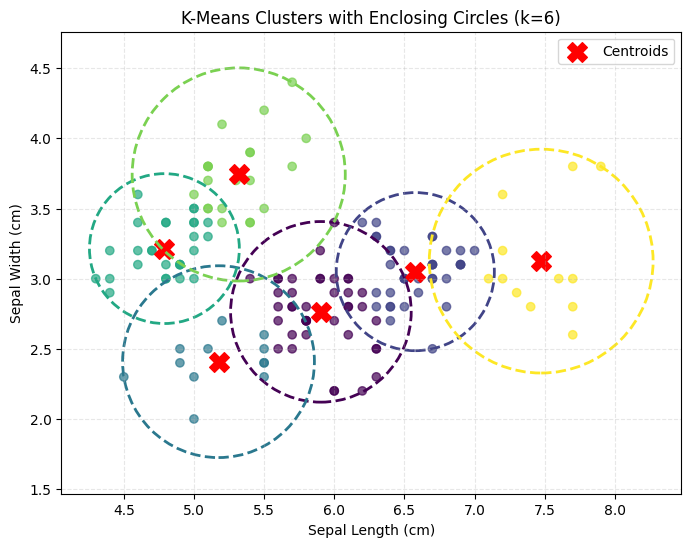

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from sklearn.cluster import KMeans

df = pd.read_csv("data/irisdata/IRIS.csv")

# Pretend we only have the sepal measurements (no species labels)
X = df[["sepal_length", "sepal_width"]].values

k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", alpha=0.7)
ax.scatter(centers[:, 0], centers[:, 1], c="red", marker="X", s=200, label="Centroids")

cmap = plt.get_cmap("viridis")
for i in range(k):
    points = X[labels == i]
    distances = np.linalg.norm(points - centers[i], axis=1)
    radius = distances.max()  # circle encloses all points in the cluster
    color = cmap(i / (k - 1)) if k > 1 else cmap(0.0)
    circle = Circle(centers[i], radius, color=color, fill=False, linewidth=2, linestyle="--")
    ax.add_patch(circle)

ax.set_xlabel("Sepal Length (cm)")
ax.set_ylabel("Sepal Width (cm)")
ax.set_title(f"K-Means Clusters with Enclosing Circles (k={k})")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_aspect("equal", adjustable="datalim")
plt.show()

Explained variance ratio:
  PC1: 72.77%
  PC2: 23.03%
  Total: 95.80%

PCA scores (PC1 and PC2 for each sample):


,sepal_length,sepal_width,petal_length,petal_width,PC1,PC2,species
0,5.1,3.5,1.4,0.2,-2.2645,0.5057,Iris-setosa
1,4.9,3.0,1.4,0.2,-2.0864,-0.6554,Iris-setosa
2,4.7,3.2,1.3,0.2,-2.3680,-0.3185,Iris-setosa
3,4.6,3.1,1.5,0.2,-2.3042,-0.5754,Iris-setosa
4,5.0,3.6,1.4,0.2,-2.3888,0.6748,Iris-setosa
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,1.8705,0.3828,Iris-virginica
146,6.3,2.5,5.0,1.9,1.5585,-0.9053,Iris-virginica
147,6.5,3.0,5.2,2.0,1.5208,0.2668,Iris-virginica
148,6.2,3.4,5.4,2.3,1.3764,1.0164,Iris-virginica



PCA loadings (feature weights for each principal component):


,PC1,PC2
sepal_length,0.5224,0.3723
sepal_width,-0.2634,0.9256
petal_length,0.5813,0.0211
petal_width,0.5656,0.0654


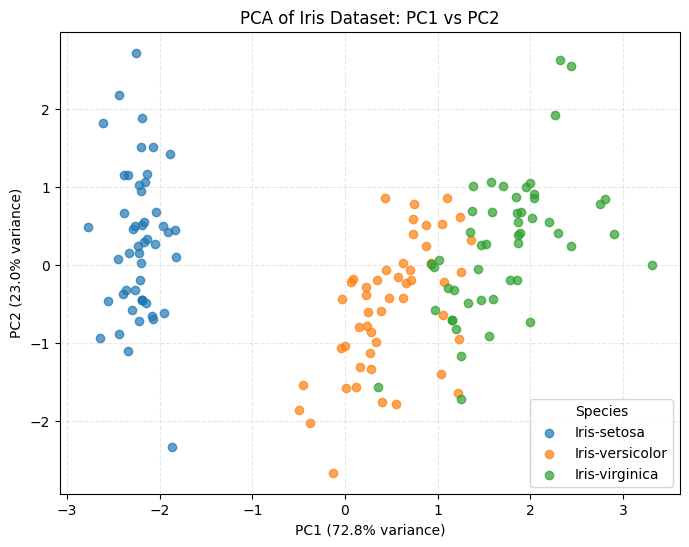

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data/irisdata/IRIS.csv")

feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = df[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(components, columns=["PC1", "PC2"])
pca_df["species"] = df["species"].values

scores_table = df[feature_cols].copy()
scores_table["PC1"] = pca_df["PC1"]
scores_table["PC2"] = pca_df["PC2"]
scores_table["species"] = pca_df["species"]

loadings_table = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=feature_cols,
)

print("Explained variance ratio:")
for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"  PC{i}: {ratio:.2%}")
print(f"  Total: {pca.explained_variance_ratio_.sum():.2%}")

print("\nPCA scores (PC1 and PC2 for each sample):")
display(scores_table.round(4))

print("\nPCA loadings (feature weights for each principal component):")
display(loadings_table.round(4))

plt.figure(figsize=(8, 6))
for species, group in pca_df.groupby("species"):
    plt.scatter(group["PC1"], group["PC2"], label=species, alpha=0.7)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA of Iris Dataset: PC1 vs PC2")
plt.legend(title="Species")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

TypeError: type 'zip' is not subscriptable

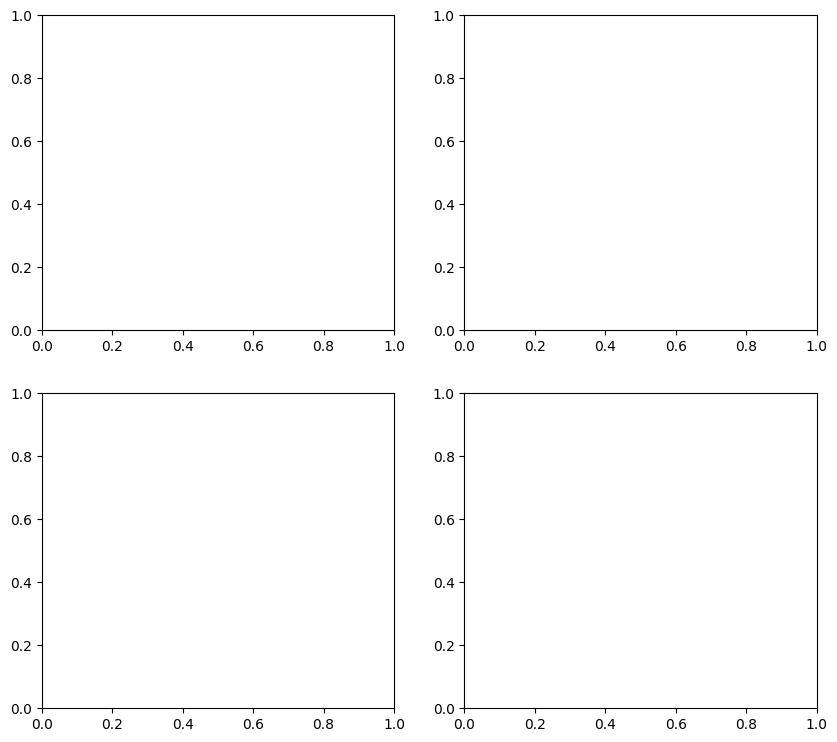

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data/irisdata/IRIS.csv")

feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = StandardScaler().fit_transform(df[feature_cols])

alpha = 1


def laplacian_kernel(x, y):
    return np.exp(-alpha * np.sum(np.abs(x - y)))


species_styles = {
    "Iris-setosa": {"marker": "s", "color": "#2196F3", "label": "Iris-setosa"},
    "Iris-versicolor": {"marker": "o", "color": "#FF5722", "label": "Iris-versicolor"},
    "Iris-virginica": {"marker": "^", "color": "#4CAF50", "label": "Iris-virginica"},
}

kernels = [
    ("a", "Linear Kernel", KernelPCA(n_components=2, kernel="linear")),
    ("b", "Polynomial kernel, degree = 2", KernelPCA(n_components=2, kernel="poly", degree=2)),
    ("c", "Gaussian (RBF) kernel (α = 1)", KernelPCA(n_components=2, kernel="rbf", gamma=alpha)),
    ("d", "Laplacian kernel (α = 1)", KernelPCA(n_components=2, kernel=laplacian_kernel)),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()

for ax, (panel, title, kpca) in zip(axes, kernels):
    components = kpca.fit_transform(X)

    for species, style in species_styles.items():
        mask = df["species"] == species
        ax.scatter(
            components[mask, 0],
            components[mask, 1],
            marker=style["marker"],
            c=style["color"],
            edgecolors="white",
            linewidths=0.6,
            s=45,
            label=style["label"],
        )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.text(0.5, -0.18, f"({panel}) {title}", transform=ax.transAxes, ha="center", va="top")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02), frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()